[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part3-causal-inference/sec3.4_causal_impact.ipynb)

# Causal Impact with Time Series

Companion notebook for **§3.4 Causal Impact with Time Series** of *Marketing
Science in Python*.

**The brief.** A national CPG brand ran an eight-week TV and PR burst
starting 2025-09-01. Nobody held out a market, and because the flight was
national there was no untreated market to hold out. Finance wants a number:
how much incremental revenue did the burst generate?

**The estimand.** Cumulative incremental revenue for the treated brand, over
the campaign weeks *and* the weeks after them, measured against the path the
brand would have taken with no campaign.

**What we have.** Four years of weekly history, plus two series the campaign
could not have reached directly: a syndicated demand index for the brand's
subcategory, and a sibling product line that received no media.

**What this notebook does.** It builds the counterfactual from statsmodels
components, then spends most of its length trying to break it: rolling-origin
validation before the campaign is ever looked at, placebo interventions on
dates where nothing happened, a multi-seed audit of what the interval is
really worth, six scenarios with known truth, and finally the same machinery
on real Dunnhumby store data, where the controls turn out to be worthless.

In [1]:
import importlib.util
import os
import sys
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Colab bootstrap: make the `msbook` helper package importable.
# Local / conda users already have it via `pip install -e .` from the repo root.
try:
    import msbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess

    _REPO_DIR = "marketing-science-in-python"
    _REPO = f"https://github.com/takechanman1228/{_REPO_DIR}.git"
    if not os.path.isdir(_REPO_DIR):
        subprocess.run(["git", "clone", "-q", _REPO, _REPO_DIR], check=True)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", _REPO_DIR,
         "-r", f"{_REPO_DIR}/notebooks/part3-causal-inference/requirements.txt"],
        check=True,
    )
    import msbook  # noqa: F401

if importlib.util.find_spec("statsmodels") is None:
    raise RuntimeError(
        "Missing Chapter 3.4 dependency: statsmodels. "
        "Install notebooks/part3-causal-inference/requirements.txt."
    )

from statsmodels.tsa.statespace.structural import UnobservedComponents

from msbook.forecasting_utils import (
    interval_coverage,
    make_forecast_origins,
    normalized_bias,
    wape,
)
from msbook.paths import chapter_generated, chapter_images

pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

DATA_DIR = chapter_generated(part="3", chapter="sec3.4-causal-impact")
IMG_DIR = chapter_images(part="3", chapter="sec3.4")

SEED = 42
CONTROLS = ["category_index", "sibling_line"]
FLIGHT_WEEKS = 8       # the campaign itself
CARRYOVER_WEEKS = 4    # the "campaign plus a little" window a stakeholder asks for
SEASONAL = [{"period": 52, "harmonics": 2}]
N_DRAWS = 1000


def dual_savefig(fig, name, **kw):
    kw.setdefault("dpi", 150)
    kw.setdefault("bbox_inches", "tight")
    fig.savefig(IMG_DIR / name, **kw)

## Where this sits

Four things get conflated whenever this analysis comes up. Separating them
up front makes the rest of the notebook easier to argue about.

| Layer | This chapter |
|---|---|
| Research design | Controlled interrupted time series, a quasi-experimental design |
| Identification | The pre-period relationship continues, and the controls were untouched by the campaign |
| Estimator | Structural time-series counterfactual fit on the pre-period only |
| Best-known implementation | Google `CausalImpact` (R), Bayesian structural time series |
| Implementation here | `statsmodels.UnobservedComponents`, every assumption visible |

Synthetic Control (§3.3) answers the same question by blending untreated
donor units. There is no donor here: the flight was national.

## 1. The data

`weekly_sales.csv` is what the analyst sees. `ground_truth.csv` carries the
untreated path the campaign replaced. **The truth is never passed to a fit.**
It is used to grade estimates and to build the failure scenarios in §6.

In [3]:
panel = pd.read_csv(DATA_DIR / "weekly_sales.csv", parse_dates=["week"])
truth = pd.read_csv(DATA_DIR / "ground_truth.csv", parse_dates=["week"])

PRE = int(np.flatnonzero(panel["campaign"].to_numpy() == 1)[0])
POST = len(panel) - PRE
FLIGHT_START = panel.loc[PRE, "week"]

weeks = panel["week"].to_numpy()
y = panel["brand_sales"].to_numpy(float)
X = panel[CONTROLS].to_numpy(float)
true_effect = truth["true_effect"].to_numpy(float)
effect_pct = truth["effect_pct"].to_numpy(float)

print(f"{len(panel)} weeks: {panel['week'].min():%Y-%m-%d} .. {panel['week'].max():%Y-%m-%d}")
print(f"pre-period {PRE} weeks, flight starts {FLIGHT_START:%Y-%m-%d} "
      f"({FLIGHT_WEEKS} weeks), {POST - FLIGHT_WEEKS} weeks observed after it")
print(f"pre-period corr(brand, category) = {np.corrcoef(y[:PRE], X[:PRE, 0])[0, 1]:.2f}, "
      f"corr(brand, sibling) = {np.corrcoef(y[:PRE], X[:PRE, 1])[0, 1]:.2f}")

236 weeks: 2021-09-06 .. 2026-03-09
pre-period 208 weeks, flight starts 2025-09-01 (8 weeks), 20 weeks observed after it
pre-period corr(brand, category) = 0.91, corr(brand, sibling) = 0.75


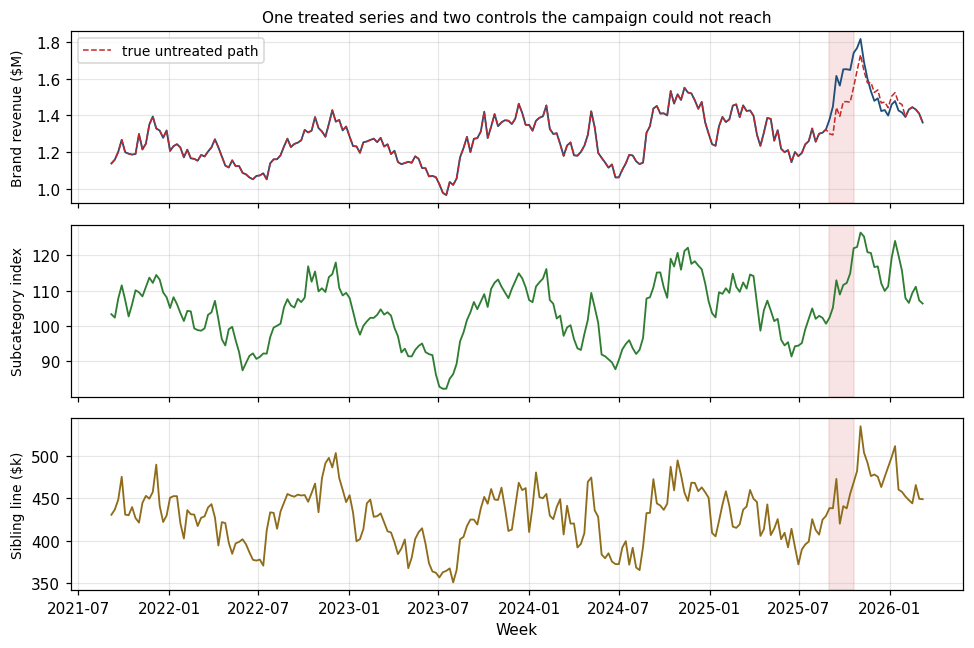

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6.0), sharex=True)
series = [("brand_sales", 1e6, "Brand revenue ($M)", "#1f4e79"),
          ("category_index", 1.0, "Subcategory index", "#2e7d32"),
          ("sibling_line", 1e3, "Sibling line ($k)", "#8e6c1a")]
for ax, (col, scale, label, color) in zip(axes, series):
    ax.plot(panel["week"], panel[col] / scale, color=color, lw=1.2)
    ax.set_ylabel(label, fontsize=9)
    ax.axvspan(FLIGHT_START, panel.loc[PRE + FLIGHT_WEEKS - 1, "week"],
               color="#c62828", alpha=0.12)
axes[0].plot(panel["week"], truth["brand_counterfactual"] / 1e6, color="#c62828",
             lw=1.0, ls="--", label="true untreated path")
axes[0].legend(fontsize=9, loc="upper left")
axes[0].set_title("One treated series and two controls the campaign could not reach",
                  fontsize=10)
axes[-1].set_xlabel("Week")
fig.align_ylabels(axes)
fig.tight_layout()
dual_savefig(fig, "01_panel_overview.png")
plt.show()

## 2. The counterfactual engine

Three steps: fit on the pre-period only, project across the post-period, read
the effect as the gap. The intervention is deliberately absent from the model,
so it can only show up in the residual.

Two choices worth stating out loud. Sales are modelled **in logs**, because a
campaign lift is multiplicative and so is seasonality; the draws are
exponentiated before anything is summed, so the effect is still reported in
dollars. And the controls enter as ordinary regressors with unconstrained
coefficients, not as a convex blend the way Synthetic Control would use them.

In [5]:
def _fit_with_restart(model):
    """Maximise the likelihood, restarting if the default search stalls.

    The likelihood surface here is flat near its optimum, so the quasi-Newton
    default occasionally stops on a line-search failure. When that happens we
    restart from a derivative-free pass and keep whichever fit has the higher
    likelihood, so the reported numbers do not depend on which optimizer path
    a particular window happened to take. `restarted` records that it fired.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = model.fit(disp=0, maxiter=1000)
        res.restarted = False
        if not res.mle_retvals.get("converged", True):
            alt = model.fit(start_params=res.params, method="powell",
                            disp=0, maxiter=2000)
            if alt.llf > res.llf:
                alt.restarted = True
                res = alt
            else:
                res.restarted = True
    return res


def fit_counterfactual(y_pre, x_pre, x_post, horizon, spec,
                       draws=N_DRAWS, seed=SEED):
    """Fit on the pre-period, then project the no-intervention path forward.

    Returns the point counterfactual, a (horizon, draws) matrix of simulated
    counterfactual paths, and the fitted results object.

    The point counterfactual is the mean of the simulated paths, not the
    exponential of the log-scale forecast. Those are different quantities once
    you leave log space, and taking both the point and the interval from the
    same draws keeps them summaries of one distribution.
    """
    kwargs = {k: v for k, v in spec.items() if k != "use_controls"}
    use = spec["use_controls"]
    exog_pre = np.log(np.asarray(x_pre, float)) if use else None
    exog_post = np.log(np.asarray(x_post, float)) if use else None

    res = _fit_with_restart(
        UnobservedComponents(
            np.log(np.asarray(y_pre, float)), exog=exog_pre, **kwargs
        )
    )
    paths = np.exp(
        np.asarray(
            res.simulate(horizon, repetitions=draws, anchor="end",
                         exog=exog_post,
                         random_state=np.random.RandomState(seed))
        ).reshape(horizon, draws)
    )
    return paths.mean(axis=1), paths, res


def cumulative_effect(y_post, point, paths, window=None):
    """Cumulative effect over the first ``window`` weeks, with a 95% interval."""
    k = len(y_post) if window is None else window
    y_post = np.asarray(y_post, float)
    estimate = float(y_post[:k].sum() - np.asarray(point, float)[:k].sum())
    totals = (y_post[:k, None] - np.asarray(paths, float)[:k]).sum(axis=0)
    lo, hi = np.percentile(totals, [2.5, 97.5])
    return estimate, float(lo), float(hi)


def seasonal_naive_forecast(y_pre, horizon, period=52):
    """Last year's same week, repeated. The floor any model has to beat."""
    y_pre = np.asarray(y_pre, float)
    return np.array([y_pre[-period + (i % period)] for i in range(horizon)])


SPECS = {
    "seasonal naive": None,
    "level, no controls": dict(level="llevel", freq_seasonal=SEASONAL,
                               use_controls=False),
    "level + controls": dict(level="llevel", freq_seasonal=SEASONAL,
                             use_controls=True),
    "trend + controls": dict(level="lltrend", freq_seasonal=SEASONAL,
                             use_controls=True),
}

## 3. Earn the forecast before you use it

The campaign is still off limits. First question: **can this model predict a
world in which nothing happened?**

Rolling-origin validation answers it. Pick origins inside the pre-period,
fit on everything up to each one, forecast the next `HORIZON` weeks, and
score against what actually happened. `HORIZON` is set to the full post
window we intend to report on, because a model can look fine over eight
weeks and fall apart over twenty-eight.

The same loop gives the second thing we need. Each pseudo-post window is a
**placebo intervention**: a date where nothing happened, run through the
whole pipeline. The cumulative "effect" it returns is what this design
produces from noise alone.

In [6]:
HORIZON = POST
MIN_TRAIN_WEEKS = 156
ORIGIN_STEP = 3

pre_panel = panel.iloc[:PRE]
origins = make_forecast_origins(
    pre_panel["week"], min_train_weeks=MIN_TRAIN_WEEKS,
    horizon=HORIZON, step=ORIGIN_STEP,
)
print(f"{len(origins)} placebo origins, {origins[0]:%Y-%m-%d} .. {origins[-1]:%Y-%m-%d} "
      f"(train >= {MIN_TRAIN_WEEKS} weeks, horizon {HORIZON} weeks)")


def backtest_spec(spec, origins, horizon):
    """Score one specification over pre-period origins where nothing happened."""
    rows, placebos, converged = [], [], []
    week_index = pre_panel["week"]
    for origin in origins:
        cut = int(np.flatnonzero(week_index.to_numpy() == np.datetime64(origin))[0]) + 1
        y_pre, y_true = y[:cut], y[cut:cut + horizon]
        x_pre, x_post = X[:cut], X[cut:cut + horizon]
        if spec is None:
            point = seasonal_naive_forecast(y_pre, horizon)
            coverage = np.nan
        else:
            point, paths, res = fit_counterfactual(y_pre, x_pre, x_post, horizon, spec)
            lower = np.percentile(paths, 2.5, axis=1)
            upper = np.percentile(paths, 97.5, axis=1)
            coverage = interval_coverage(y_true, lower, upper)
            placebos.append(cumulative_effect(y_true, point, paths))
            converged.append(not getattr(res, "restarted", False))
        rows.append({"wape": wape(y_true, point),
                     "bias": normalized_bias(y_true, point),
                     "coverage": coverage})
    return pd.DataFrame(rows), placebos, converged


backtest, placebo_by_spec, converged_flags = {}, {}, []
for name, spec in SPECS.items():
    scored, placebos, converged = backtest_spec(spec, origins, HORIZON)
    backtest[name] = scored.mean()
    placebo_by_spec[name] = placebos
    converged_flags.extend(converged)

backtest_table = pd.DataFrame(backtest).T
backtest_table.columns = ["WAPE", "bias", "interval coverage"]
print("\nRolling-origin validation, pre-period only")
for name, row in backtest_table.iterrows():
    cover = "     n/a" if np.isnan(row["interval coverage"]) else f"{100 * row['interval coverage']:7.1f}%"
    print(f"{name:22s} WAPE {100 * row['WAPE']:5.2f}%   bias {100 * row['bias']:+6.2f}%   coverage {cover}")

CHOSEN = "trend + controls"
print(f"\nChosen specification: {CHOSEN}")
print(f"Optimizer restarted on {len(converged_flags) - sum(converged_flags)} of "
      f"{len(converged_flags)} structural fits")

9 placebo origins, 2024-08-26 .. 2025-02-10 (train >= 156 weeks, horizon 28 weeks)



Rolling-origin validation, pre-period only
seasonal naive         WAPE  7.96%   bias  -5.83%   coverage      n/a
level, no controls     WAPE  5.54%   bias  -1.32%   coverage    99.6%
level + controls       WAPE  2.62%   bias  -0.60%   coverage    96.8%
trend + controls       WAPE  2.43%   bias  +0.48%   coverage    87.7%

Chosen specification: trend + controls
Optimizer restarted on 1 of 27 structural fits


Three things fall out of that table, and only the first is the one people
usually look for.

1. The structural model beats the seasonal-naive floor by roughly threefold,
   so the machinery earns its complexity.
2. Dropping the controls roughly doubles the error. On this data they are
   not decoration.
3. `level + controls` and `trend + controls` look close on error, but the
   level-only version drifts: the brand grows faster than its category, and
   with no trend term that gap is charged to the campaign. Validating at the
   horizon you intend to report is what surfaces this.

In [7]:
placebo_totals = np.array([p[0] for p in placebo_by_spec[CHOSEN]])
placebo_significant = np.mean(
    [(lo > 0) or (hi < 0) for _, lo, hi in placebo_by_spec[CHOSEN]]
)
print(f"Placebo windows ({CHOSEN}): mean ${placebo_totals.mean():,.0f}, "
      f"largest magnitude ${np.abs(placebo_totals).max():,.0f}")
print(f"Placebo windows whose interval excludes zero: {100 * placebo_significant:.0f}%")

Placebo windows (trend + controls): mean $-190,307, largest magnitude $636,191
Placebo windows whose interval excludes zero: 11%


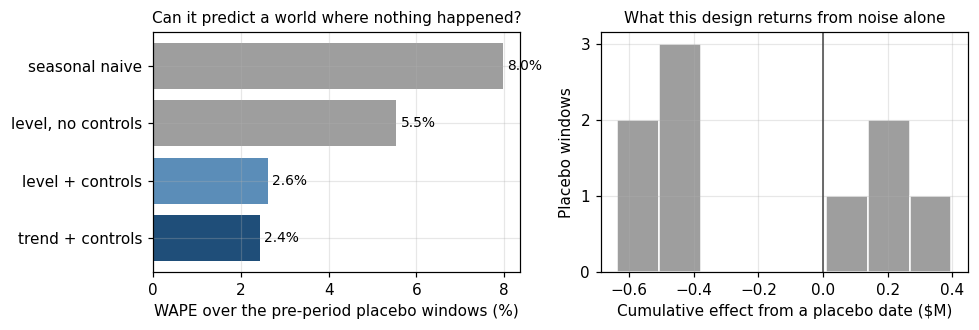

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.1))
names = list(backtest_table.index)
axes[0].barh(names, 100 * backtest_table["WAPE"],
             color=["#9e9e9e", "#9e9e9e", "#5b8db8", "#1f4e79"])
axes[0].set_xlabel("WAPE over the pre-period placebo windows (%)")
axes[0].set_title("Can it predict a world where nothing happened?", fontsize=10)
axes[0].invert_yaxis()
for i, v in enumerate(100 * backtest_table["WAPE"]):
    axes[0].text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=9)

axes[1].hist(placebo_totals / 1e6, bins=8, color="#9e9e9e", edgecolor="white")
axes[1].axvline(0, color="#444444", lw=1)
axes[1].set_xlabel("Cumulative effect from a placebo date ($M)")
axes[1].set_ylabel("Placebo windows")
axes[1].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[1].set_title("What this design returns from noise alone", fontsize=10)
fig.tight_layout()
dual_savefig(fig, "02_validation_and_placebo.png")
plt.show()

## 4. Read the campaign

Only now does the campaign window get used.

In [9]:
point_cf, paths_cf, res_cf = fit_counterfactual(
    y[:PRE], X[:PRE], X[PRE:], POST, SPECS[CHOSEN]
)
y_post = y[PRE:]
lower_cf = np.percentile(paths_cf, 2.5, axis=1)
upper_cf = np.percentile(paths_cf, 97.5, axis=1)

pointwise = y_post - point_cf
cumulative = np.cumsum(pointwise)
true_cumulative = np.cumsum(true_effect[PRE:])

beta_names = [n for n in res_cf.model.param_names if n.startswith("beta")]
betas = dict(zip(CONTROLS, [float(np.asarray(res_cf.params)[res_cf.model.param_names.index(n)])
                            for n in beta_names]))
print("Fitted control elasticities (log-log):",
      ", ".join(f"{k} {v:+.2f}" for k, v in betas.items()))

Fitted control elasticities (log-log): category_index +0.79, sibling_line +0.15


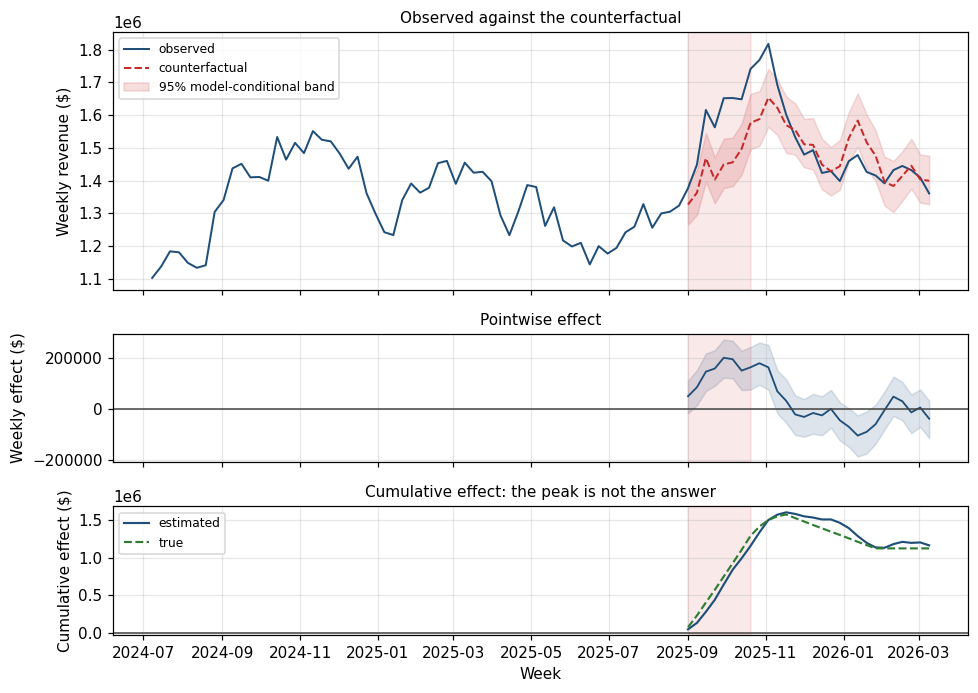

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6.4), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1, 1]})
show_from = PRE - 60
wk = panel["week"]

axes[0].plot(wk[show_from:], y[show_from:], color="#1f4e79", lw=1.3, label="observed")
axes[0].plot(wk[PRE:], point_cf, color="#c62828", lw=1.3, ls="--", label="counterfactual")
axes[0].fill_between(wk[PRE:], lower_cf, upper_cf, color="#c62828", alpha=0.15,
                     label="95% model-conditional band")
axes[0].set_ylabel("Weekly revenue ($)")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].set_title("Observed against the counterfactual", fontsize=10)

axes[1].plot(wk[PRE:], pointwise, color="#1f4e79", lw=1.2)
axes[1].fill_between(wk[PRE:], y_post - upper_cf, y_post - lower_cf,
                     color="#1f4e79", alpha=0.15)
axes[1].axhline(0, color="#444444", lw=1)
axes[1].set_ylabel("Weekly effect ($)")
axes[1].set_title("Pointwise effect", fontsize=10)

axes[2].plot(wk[PRE:], cumulative, color="#1f4e79", lw=1.4, label="estimated")
axes[2].plot(wk[PRE:], true_cumulative, color="#2e7d32", lw=1.4, ls="--", label="true")
axes[2].axhline(0, color="#444444", lw=1)
axes[2].set_ylabel("Cumulative effect ($)")
axes[2].set_title("Cumulative effect: the peak is not the answer", fontsize=10)
axes[2].legend(fontsize=8, loc="upper left")
axes[2].set_xlabel("Week")

for ax in axes:
    ax.axvspan(FLIGHT_START, panel.loc[PRE + FLIGHT_WEEKS - 1, "week"],
               color="#c62828", alpha=0.10)
fig.tight_layout()
dual_savefig(fig, "03_impact_three_panel.png")
plt.show()

## 5. Which window is the answer?

The cumulative curve climbs through the flight, keeps climbing while the
carryover runs, then gives part of it back. Three defensible-sounding
reporting windows produce three different numbers.

In [11]:
WINDOWS = {
    "Flight only (8 weeks)": FLIGHT_WEEKS,
    "Flight + carryover (12 weeks)": FLIGHT_WEEKS + CARRYOVER_WEEKS,
    f"Full post window ({POST} weeks)": POST,
}
window_rows = []
for label, k in WINDOWS.items():
    est, lo, hi = cumulative_effect(y_post, point_cf, paths_cf, window=k)
    tru = float(true_effect[PRE:PRE + k].sum())
    window_rows.append({
        "window": label, "estimate": est, "lower": lo, "upper": hi,
        "truth": tru, "error_pct": 100 * (est - tru) / tru,
    })
windows_df = pd.DataFrame(window_rows)

print("Reporting window")
for r in window_rows:
    print(f"{r['window']:32s} est ${r['estimate']:>10,.0f}  "
          f"[{r['lower']:>10,.0f}, {r['upper']:>10,.0f}]  "
          f"true ${r['truth']:>10,.0f}  err {r['error_pct']:+6.1f}%")

overstatement = 100 * (window_rows[1]["estimate"] / window_rows[2]["estimate"] - 1)
print(f"\nStopping at the cumulative peak overstates the full-window answer "
      f"by {overstatement:.0f}%.")

Reporting window
Flight only (8 weeks)            est $ 1,156,557  [   844,016,  1,445,801]  true $ 1,290,678  err  -10.4%
Flight + carryover (12 weeks)    est $ 1,602,613  [ 1,173,707,  1,996,012]  true $ 1,573,504  err   +1.8%
Full post window (28 weeks)      est $ 1,164,451  [   411,060,  1,890,035]  true $ 1,123,976  err   +3.6%

Stopping at the cumulative peak overstates the full-window answer by 38%.


## 6. Two kinds of uncertainty

The band on the chart is a **model-conditional** interval: it holds the
fitted parameters fixed and propagates the state and observation noise. It
is a floor on the true uncertainty, not the whole of it.

There are two ways to find out what it is actually worth. The placebo
windows from §3 give an empirical yardstick on this dataset. A multi-seed
audit re-fits the chosen specification on fresh draws from the same
generator and asks how often the interval contains the truth.

Two limits are worth stating. The specification was chosen once, on the
committed draw, and is held fixed here, so this measures the estimator and
not the selection step in front of it. And the audit is itself a sample, so
each rate below is reported with its own interval.

The null run draws a *separate* world with no campaign in it. Reusing the
treated draw's own counterfactual would look like a null test but would not
be one: the pre-period is identical, so the fit and its simulated paths come
back the same, and the false-positive rate collapses into one minus the
coverage rate.

In [12]:
placebo_p = float(np.mean(np.abs(placebo_totals) >= abs(window_rows[2]["estimate"])))
print(f"Estimated effect (full window): ${window_rows[2]['estimate']:,.0f}")
print(f"Largest placebo effect:         ${np.abs(placebo_totals).max():,.0f}")
print(f"Placebo windows at least as large: {100 * placebo_p:.0f}%")

Estimated effect (full window): $1,164,451
Largest placebo effect:         $636,191
Placebo windows at least as large: 0%


In [13]:
N_AUDIT = 200
AUDIT_SEED_START = 1000
NULL_SEED_OFFSET = 500_000

from msbook.paths import NOTEBOOKS_DIR

sys.path.insert(0, str(NOTEBOOKS_DIR / "part3-causal-inference"))
import causal_impact_data_generation as datagen  # noqa: E402


def audit_once(seed, spec):
    """Re-fit on a fresh draw. Returns error, coverage, and the calls made."""
    tables = datagen.generate_dataset(seed=seed)
    p, t = tables["panel"], tables["truth"]
    ya = p["brand_sales"].to_numpy(float)
    xa = p[CONTROLS].to_numpy(float)
    pre = int(np.flatnonzero(p["campaign"].to_numpy() == 1)[0])
    horizon = len(p) - pre
    tru = float(t["true_effect"].to_numpy()[pre:].sum())

    pt, pa, res = fit_counterfactual(ya[:pre], xa[:pre], xa[pre:], horizon, spec)
    est, lo, hi = cumulative_effect(ya[pre:], pt, pa)

    # The null run needs its own world. Reusing this draw's counterfactual
    # would re-fit the identical pre-period with the identical seed, so its
    # interval would be this one shifted by the true effect, and "false
    # positive" would be the arithmetic complement of "covered" rather than a
    # separate measurement.
    null_tables = datagen.generate_dataset(seed=seed + NULL_SEED_OFFSET)
    null = null_tables["truth"]["brand_counterfactual"].to_numpy(float)
    xn = null_tables["panel"][CONTROLS].to_numpy(float)
    pt0, pa0, res0 = fit_counterfactual(null[:pre], xn[:pre], xn[pre:], horizon, spec)
    _, lo0, hi0 = cumulative_effect(null[pre:], pt0, pa0)

    return {"rel_error": (est - tru) / tru,
            "covered": lo <= tru <= hi,
            "called_positive": lo > 0,
            "false_positive": (lo0 > 0) or (hi0 < 0),
            "restarted": (getattr(res, "restarted", False)
                          or getattr(res0, "restarted", False))}


audit = pd.DataFrame([audit_once(s, SPECS[CHOSEN])
                      for s in range(AUDIT_SEED_START, AUDIT_SEED_START + N_AUDIT)])
audit_summary = {
    "mean relative bias": 100 * audit["rel_error"].mean(),
    "median absolute error": 100 * audit["rel_error"].abs().median(),
    "interval coverage": 100 * audit["covered"].mean(),
    "effect called positive": 100 * audit["called_positive"].mean(),
    "false positives under the null": 100 * audit["false_positive"].mean(),
}
RATE_COLUMNS = {
    "interval coverage": "covered",
    "effect called positive": "called_positive",
    "false positives under the null": "false_positive",
}


def wilson_interval(successes, n, z=1.96):
    """95% interval for a proportion, so a rate is never read as exact."""
    if n == 0:
        return float("nan"), float("nan")
    phat = successes / n
    denom = 1.0 + z**2 / n
    centre = (phat + z**2 / (2 * n)) / denom
    half = z * np.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2)) / denom
    return 100 * (centre - half), 100 * (centre + half)


print(f"Simulation audit over {N_AUDIT} fresh draws of the same design")
for k, v in audit_summary.items():
    if k in RATE_COLUMNS:
        lo_r, hi_r = wilson_interval(int(audit[RATE_COLUMNS[k]].sum()), len(audit))
        print(f"  {k:32s} {v:5.0f}%  95% interval {lo_r:.0f}% to {hi_r:.0f}%")
    else:
        print(f"  {k:32s} {v:5.0f}%")
print(f"  {'optimizer restarts':32s} "
      f"{int(audit['restarted'].sum())} of {len(audit)} draws")

Simulation audit over 200 fresh draws of the same design
  mean relative bias                  -5%
  median absolute error               34%
  interval coverage                   90%  95% interval 84% to 93%
  effect called positive              60%  95% interval 53% to 67%
  false positives under the null       9%  95% interval 6% to 14%
  optimizer restarts               28 of 200 draws


## 7. Break it on purpose

Every scenario below is a deterministic transform of the same draw, so the
only thing that changes is the one assumption under test. The ground truth
is recomputed for each so the estimates stay comparable.

In [14]:
SHOCK_START = 2          # weeks into the flight
SHOCK_LENGTH = 3
SHOCK_FACTOR = 0.85      # a category-wide 15% dip
LEAK_SHARE = 0.35        # share of the brand's lift that reached the category index
BREAK_FACTOR = 1.05      # post-period category growth the brand did not share

NO_CONTROLS = dict(level="llevel", freq_seasonal=SEASONAL, use_controls=False)


def apply_market_shock(y_in, x_in, effect_in, start, length, factor):
    """A category-wide dip that hits the brand and both controls alike."""
    window = slice(start, start + length)
    y_out, x_out, e_out = y_in.copy(), x_in.copy(), effect_in.copy()
    y_out[window] *= factor
    x_out[window] *= factor
    e_out[window] *= factor
    return y_out, x_out, e_out


def contaminate_control(x_in, effect_share, share, column=0):
    """Leak part of the campaign's lift into a control series."""
    x_out = x_in.copy()
    x_out[:, column] *= 1.0 + share * np.clip(effect_share, 0.0, None)
    return x_out


def break_relationship(x_in, pre, factor, column=0):
    """The control grows in the post-period for a reason the brand misses out on."""
    x_out = x_in.copy()
    x_out[pre:, column] *= factor
    return x_out


def run_scenario(label, y_in, x_in, true_total, spec):
    point, paths, _ = fit_counterfactual(y_in[:PRE], x_in[:PRE], x_in[PRE:], POST, spec)
    est, lo, hi = cumulative_effect(y_in[PRE:], point, paths)
    return {"scenario": label, "estimate": est, "lower": lo, "upper": hi,
            "truth": true_total, "error_pct": 100 * (est - true_total) / true_total,
            "covered": lo <= true_total <= hi, "excludes_zero": lo > 0}


true_clean = float(true_effect[PRE:].sum())
y_shock, X_shock, effect_shock = apply_market_shock(
    y, X, true_effect, PRE + SHOCK_START, SHOCK_LENGTH, SHOCK_FACTOR
)
true_shock = float(effect_shock[PRE:].sum())

scenarios = pd.DataFrame([
    run_scenario("A. Clean, with controls", y, X, true_clean, SPECS[CHOSEN]),
    run_scenario("B. Clean, no controls", y, X, true_clean, NO_CONTROLS),
    run_scenario("C. Market shock, no controls", y_shock, X_shock, true_shock, NO_CONTROLS),
    run_scenario("D. Market shock, with controls", y_shock, X_shock, true_shock, SPECS[CHOSEN]),
    run_scenario("E. Contaminated control", y,
                 contaminate_control(X, effect_pct, LEAK_SHARE), true_clean, SPECS[CHOSEN]),
    run_scenario("F. Relationship break", y,
                 break_relationship(X, PRE, BREAK_FACTOR), true_clean, SPECS[CHOSEN]),
])

print("Scenario")
for r in scenarios.to_dict("records"):
    print(f"{r['scenario']:32s} est ${r['estimate']:>10,.0f}  "
          f"[{r['lower']:>10,.0f}, {r['upper']:>10,.0f}]  "
          f"true ${r['truth']:>10,.0f}  err {r['error_pct']:+7.1f}%  "
          f"truth in interval: {'yes' if r['covered'] else 'NO'}")

width_ratio = ((scenarios.loc[1, "upper"] - scenarios.loc[1, "lower"])
               / (scenarios.loc[0, "upper"] - scenarios.loc[0, "lower"]))
kept_share = 100 * scenarios.loc[4, "estimate"] / true_clean
print(f"\nControls narrow the interval by {width_ratio:.1f}x, and they earned it: "
      f"they also cut backtest error from "
      f"{100 * backtest_table.loc['level, no controls', 'WAPE']:.1f}% to "
      f"{100 * backtest_table.loc[CHOSEN, 'WAPE']:.1f}%.")
print(f"A {LEAK_SHARE:.0%} leak into the most predictive control keeps "
      f"{kept_share:.0f}% of the true effect, and the interval no longer excludes zero.")

Scenario
A. Clean, with controls          est $ 1,164,451  [   411,060,  1,890,035]  true $ 1,123,976  err    +3.6%  truth in interval: yes
B. Clean, no controls            est $ 1,555,093  [-8,159,563,  9,271,771]  true $ 1,123,976  err   +38.4%  truth in interval: yes
C. Market shock, no controls     est $   830,676  [-8,883,980,  8,547,354]  true $ 1,046,360  err   -20.6%  truth in interval: yes
D. Market shock, with controls   est $ 1,060,038  [   327,654,  1,794,611]  true $ 1,046,360  err    +1.3%  truth in interval: yes
E. Contaminated control          est $   732,919  [   -29,259,  1,491,235]  true $ 1,123,976  err   -34.8%  truth in interval: yes
F. Relationship break            est $  -460,029  [-1,237,200,    317,437]  true $ 1,123,976  err  -140.9%  truth in interval: NO

Controls narrow the interval by 11.8x, and they earned it: they also cut backtest error from 5.5% to 2.4%.
A 35% leak into the most predictive control keeps 65% of the true effect, and the interval no long

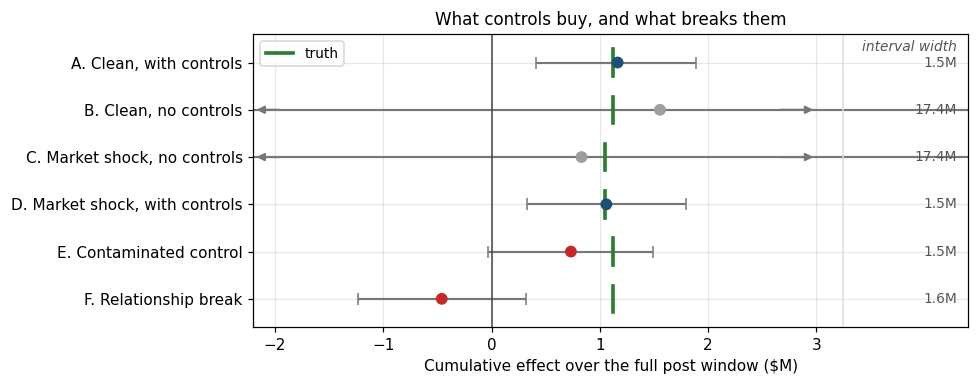

In [15]:
fig, ax = plt.subplots(figsize=(9, 3.6))
order = list(range(len(scenarios)))
colors = ["#1f4e79", "#9e9e9e", "#9e9e9e", "#1f4e79", "#c62828", "#c62828"]
est = scenarios["estimate"].to_numpy() / 1e6
lo = scenarios["lower"].to_numpy() / 1e6
hi = scenarios["upper"].to_numpy() / 1e6

# Two scenarios have intervals many times wider than the rest. Clip the axis so
# the informative comparisons stay readable, and print each width alongside.
X_MIN, X_MAX, WIDTH_COL = -2.2, 3.0, 4.3
ax.errorbar(est, order, xerr=[est - lo, hi - est], fmt="none", ecolor="#777777",
            elinewidth=1.4, capsize=4)
ax.scatter(est, order, c=colors, zorder=3, s=45)
for i, t in enumerate(scenarios["truth"].to_numpy() / 1e6):
    ax.plot([t, t], [i - 0.28, i + 0.28], color="#2e7d32", lw=2.4,
            label="truth" if i == 0 else None)
for i, (low, high) in enumerate(zip(lo, hi)):
    ax.text(WIDTH_COL, i, f"{high - low:.1f}M", va="center", ha="right",
            fontsize=9, color="#555555")
    for edge, side in ((low, X_MIN), (high, X_MAX)):
        if (edge < X_MIN) or (edge > X_MAX):
            ax.annotate("", xy=(side, i), xytext=(side * 0.88, i),
                        arrowprops=dict(arrowstyle="-|>", color="#777777", lw=1.4))
ax.text(WIDTH_COL, -0.32, "interval width", va="center", ha="right",
        fontsize=9, color="#555555", style="italic")
ax.axvline(0, color="#444444", lw=1)
ax.axvline(X_MAX + 0.25, color="#dddddd", lw=1)
ax.set_xlim(X_MIN, WIDTH_COL + 0.1)
ax.set_xticks([-2, -1, 0, 1, 2, 3])
ax.set_yticks(order)
ax.set_yticklabels(scenarios["scenario"])
ax.set_ylim(len(order) - 0.4, -0.6)
ax.set_xlabel("Cumulative effect over the full post window ($M)")
ax.set_title("What controls buy, and what breaks them", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
fig.tight_layout()
dual_savefig(fig, "04_scenarios.png")
plt.show()

## 8. Reality check on real data

Everything above is a world we built. The last section runs the same
machinery on real Dunnhumby store data: take store 367's weekly sales,
multiply the final twelve weeks by 1.15, and try to recover the planted lift
with the four other stores as controls.

The lift comes back. The diagnostics are the interesting part, and the tool
that settles it is the one from section 3: does adding the controls improve
an out-of-sample forecast?

In [16]:
daily = pd.read_parquet(DATA_DIR / "dunnhumby_store_daily.parquet")
daily["ds"] = pd.to_datetime(daily["ds"])
weekly = (
    daily[daily["unique_id"] != "chain_total"]
    .set_index("ds")
    .groupby("unique_id")["y"]
    .resample("W-MON", label="left", closed="left")
    .sum()
    .reset_index()
)
wide = weekly.pivot(index="ds", columns="unique_id", values="y").sort_index().iloc[1:-1]

DH_TARGET = "store_367"
DH_CONTROLS = ["store_292", "store_356", "store_381", "store_406"]
DH_POST = 12
DH_LIFT = 0.15
DH_BURN_IN = 12

corr_before = float(wide.corr().loc[DH_TARGET, DH_CONTROLS].mean())
wide = wide.iloc[DH_BURN_IN:]
corr_after = float(wide.corr().loc[DH_TARGET, DH_CONTROLS].mean())
print(f"{len(wide)} weeks after trimming the household-enrollment ramp")
print(f"mean corr(target, controls): {corr_before:.2f} before trimming "
      f"-> {corr_after:.2f} after")

dh_baseline = wide[DH_TARGET].to_numpy(float)
dh_X = wide[DH_CONTROLS].to_numpy(float)
dh_pre = len(wide) - DH_POST

88 weeks after trimming the household-enrollment ramp
mean corr(target, controls): 0.45 before trimming -> 0.01 after


The correlation that made these stores look like controls was a shared
onboarding ramp: the Dunnhumby household panel starts small and grows, so
every store rises together for reasons that have nothing to do with demand.
Trim the ramp and the co-movement is gone.

That is a warning, not a verdict. The verdict comes from a backtest.

In [17]:
DH_SPEC = dict(level="llevel", use_controls=True)
DH_SPEC_NO = dict(level="llevel", use_controls=False)

dh_origins = make_forecast_origins(
    pd.Series(wide.index), min_train_weeks=40, horizon=DH_POST, step=4
)
dh_backtest = {}
for label, spec in [("with controls", DH_SPEC), ("without controls", DH_SPEC_NO)]:
    errors = []
    for origin in dh_origins:
        cut = int(np.flatnonzero(wide.index.to_numpy() == np.datetime64(origin))[0]) + 1
        point, _, _ = fit_counterfactual(
            dh_baseline[:cut], dh_X[:cut], dh_X[cut:cut + DH_POST], DH_POST, spec
        )
        errors.append(wape(dh_baseline[cut:cut + DH_POST], point))
    dh_backtest[label] = float(np.mean(errors))

print(f"Rolling-origin backtest on the untouched series, {len(dh_origins)} origins")
for label, value in dh_backtest.items():
    print(f"  {label:18s} WAPE {100 * value:.2f}%")

Rolling-origin backtest on the untouched series, 10 origins
  with controls      WAPE 13.77%
  without controls   WAPE 13.74%


In [18]:
dh_y = dh_baseline.copy()
dh_y[dh_pre:] *= 1.0 + DH_LIFT
dh_truth = float(DH_LIFT * dh_baseline[dh_pre:].sum())

dh_point, dh_paths, dh_res = fit_counterfactual(
    dh_y[:dh_pre], dh_X[:dh_pre], dh_X[dh_pre:], DH_POST, DH_SPEC
)
dh_est, dh_lo, dh_hi = cumulative_effect(dh_y[dh_pre:], dh_point, dh_paths)
dh_point0, dh_paths0, _ = fit_counterfactual(
    dh_y[:dh_pre], dh_X[:dh_pre], dh_X[dh_pre:], DH_POST, DH_SPEC_NO
)
dh_est0, dh_lo0, dh_hi0 = cumulative_effect(dh_y[dh_pre:], dh_point0, dh_paths0)

dh_betas = np.array([float(np.asarray(dh_res.params)[dh_res.model.param_names.index(n)])
                     for n in dh_res.model.param_names if n.startswith("beta")])
print(f"planted lift      {dh_truth:>9,.0f} units")
print(f"with controls     {dh_est:>9,.0f}  [{dh_lo:,.0f}, {dh_hi:,.0f}]  "
      f"width {dh_hi - dh_lo:,.0f}")
print(f"without controls  {dh_est0:>9,.0f}  [{dh_lo0:,.0f}, {dh_hi0:,.0f}]  "
      f"width {dh_hi0 - dh_lo0:,.0f}")
print(f"control elasticities: {np.round(dh_betas, 3).tolist()}")

planted lift          1,775 units
with controls         1,833  [492, 3,101]  width 2,609
without controls      1,601  [-1,531, 4,256]  width 5,788
control elasticities: [-0.008, 0.113, -0.046, -0.048]


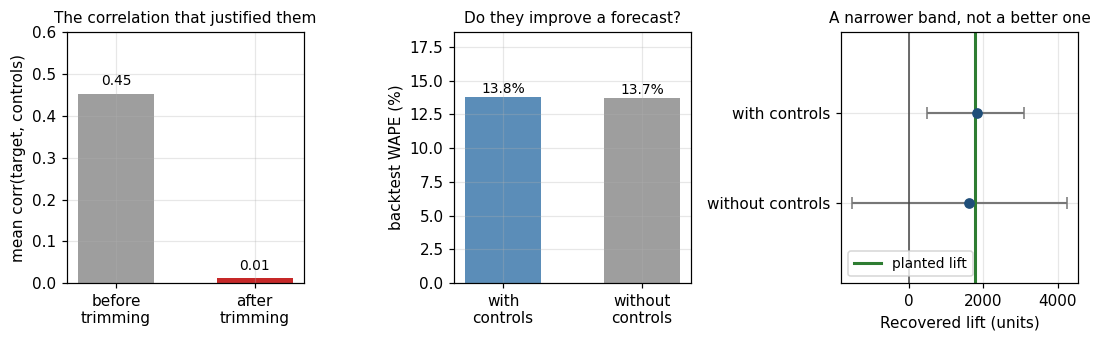

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))

axes[0].bar(["before\ntrimming", "after\ntrimming"], [corr_before, corr_after],
            color=["#9e9e9e", "#c62828"], width=0.55)
axes[0].set_ylabel("mean corr(target, controls)")
axes[0].set_ylim(0, 0.6)
axes[0].set_title("The correlation that justified them", fontsize=10)
for i, v in enumerate([corr_before, corr_after]):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

bt = [100 * dh_backtest["with controls"], 100 * dh_backtest["without controls"]]
axes[1].bar(["with\ncontrols", "without\ncontrols"], bt,
            color=["#5b8db8", "#9e9e9e"], width=0.55)
axes[1].set_ylabel("backtest WAPE (%)")
axes[1].set_ylim(0, max(bt) * 1.35)
axes[1].set_title("Do they improve a forecast?", fontsize=10)
for i, v in enumerate(bt):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

ests = np.array([dh_est, dh_est0])
axes[2].errorbar(ests, [0, 1],
                 xerr=[ests - np.array([dh_lo, dh_lo0]),
                       np.array([dh_hi, dh_hi0]) - ests],
                 fmt="o", color="#1f4e79", ecolor="#777777", elinewidth=1.4, capsize=4)
axes[2].axvline(dh_truth, color="#2e7d32", lw=2.0, label="planted lift")
axes[2].axvline(0, color="#444444", lw=1)
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(["with controls", "without controls"])
axes[2].set_ylim(1.9, -0.9)
axes[2].set_xlabel("Recovered lift (units)")
axes[2].legend(fontsize=9, loc="lower left")
axes[2].set_title("A narrower band, not a better one", fontsize=10)

fig.tight_layout()
dual_savefig(fig, "05_dunnhumby_reality_check.png")
plt.show()

The planted lift comes back, and it would be easy to write that up as a
success. It is not one.

The backtest is flat: adding the four control stores does not improve an
out-of-sample forecast of the untouched series at all. The fitted
elasticities are all near zero, two of them negative. Each store's weekly
wiggle is the shopping of a few thousand sampled households, idiosyncratic
noise no other store can predict.

The narrower interval is the trap. Four extra regressors soak up in-sample
variation, the fitted level variance collapses, and the band tightens even
though the forecast did not get better. **A narrower interval is not
evidence that the controls helped. The backtest is.**

What actually produced the number is a projection of store 367's own recent
level. That is a weak design, not a successful controlled analysis. The
honest next moves are the ones the previous chapter and Chapter 6.3
describe: find markets that can carry a donor blend, or randomize the geos
next time.

## Key numbers

The block below is what the chapter quotes. If re-executing this notebook
moves a number, the chapter text has to move with it.

In [20]:
print("Key numbers")
print(f"Weeks                              {len(panel)}")
print(f"Pre-period weeks                   {PRE}")
print(f"Placebo origins                    {len(origins)}")
for name, row in backtest_table.iterrows():
    cover = "n/a" if np.isnan(row["interval coverage"]) else f"{100 * row['interval coverage']:.1f}%"
    print(f"Backtest {name:22s} {100 * row['WAPE']:6.2f}% {100 * row['bias']:+7.2f}% {cover:>7s}")
for r in window_rows:
    print(f"Window {r['window']:32s} {r['estimate']:12,.0f} {r['lower']:12,.0f} "
          f"{r['upper']:12,.0f} {r['truth']:12,.0f} {r['error_pct']:+7.1f}%")
print(f"Peak-window overstatement          {overstatement:.0f}%")
print(f"Placebo largest magnitude          {np.abs(placebo_totals).max():,.0f}")
print(f"Placebo at least as large          {100 * placebo_p:.0f}%")
for k, v in audit_summary.items():
    if k in RATE_COLUMNS:
        lo_r, hi_r = wilson_interval(int(audit[RATE_COLUMNS[k]].sum()), len(audit))
        print(f"Audit {k:32s} {v:.0f}% {lo_r:.0f}% {hi_r:.0f}%")
    else:
        print(f"Audit {k:32s} {v:.0f}%")
print(f"Audit draws                        {N_AUDIT}")
print(f"Audit optimizer restarts           {int(audit['restarted'].sum())}")
print(f"Backtest optimizer restarts        "
      f"{len(converged_flags) - sum(converged_flags)} of {len(converged_flags)}")
for r in scenarios.to_dict("records"):
    print(f"Scenario {r['scenario']:32s} {r['estimate']:12,.0f} {r['lower']:12,.0f} "
          f"{r['upper']:12,.0f} {r['error_pct']:+8.1f}%")
print(f"Control interval narrowing         {width_ratio:.1f}x")
print(f"Contaminated control keeps         {kept_share:.0f}%")
print(f"Dunnhumby corr before/after ramp   {corr_before:.2f} {corr_after:.2f}")
print(f"Dunnhumby backtest with/without    {100 * dh_backtest['with controls']:.1f}% "
      f"{100 * dh_backtest['without controls']:.1f}%")
print(f"Dunnhumby largest elasticity       {np.abs(dh_betas).max():.2f}")
print(f"Dunnhumby planted/recovered        {dh_truth:,.0f} {dh_est:,.0f}")

Key numbers
Weeks                              236
Pre-period weeks                   208
Placebo origins                    9
Backtest seasonal naive           7.96%   -5.83%     n/a
Backtest level, no controls       5.54%   -1.32%   99.6%
Backtest level + controls         2.62%   -0.60%   96.8%
Backtest trend + controls         2.43%   +0.48%   87.7%
Window Flight only (8 weeks)               1,156,557      844,016    1,445,801    1,290,678   -10.4%
Window Flight + carryover (12 weeks)       1,602,613    1,173,707    1,996,012    1,573,504    +1.8%
Window Full post window (28 weeks)         1,164,451      411,060    1,890,035    1,123,976    +3.6%
Peak-window overstatement          38%
Placebo largest magnitude          636,191
Placebo at least as large          0%
Audit mean relative bias               -5%
Audit median absolute error            34%
Audit interval coverage                90% 84% 93%
Audit effect called positive           60% 53% 67%
Audit false positives under the nu

## So what for the chapter

- A structural counterfactual with good controls recovers a known effect on
  this design, but the interval it prints is a floor. The audit puts its real
  coverage below its nominal 95%, and it calls a genuine effect significant
  only about half the time at this scale.
- The reporting window is a bigger lever than the model. Stopping at the peak
  of the cumulative curve books demand the brand is about to give back.
- Controls exist to absorb market-wide shocks, and the more predictive a
  control is, the more likely the campaign touched it. A leak into the best
  control silently took the estimate below significance while every
  diagnostic stayed green.
- A relationship that held for four years and then stopped is the one failure
  no fit statistic reports and no interval covers.
- On real store data the same machinery returns a number, but the controls
  do not improve an out-of-sample forecast at all. The interval gets narrower
  anyway. That is a weak design wearing a tight band.